# Image processing — radiometry, cloud masks, indices

Walk through the three RS operator modules end-to-end on a synthetic
Sentinel-2 L2A chip:

1. **`geotoolz.radiometry`** — convert raw DN to top-of-atmosphere
   reflectance, then stretch / gamma-correct for display.
2. **`geotoolz.cloud`** — build a boolean mask from the Sen2Cor SCL
   band, drop cloudy pixels.
3. **`geotoolz.indices`** — compute NDVI on the cleaned reflectance.

Every step is shown twice: first manually, then composed into a single
`Sequential`. The two should produce identical output.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from georeader.geotensor import GeoTensor

import geotoolz as gz

## 1. Build a synthetic S2 L2A chip

Real Sentinel-2 L2A scenes ship the spectral bands in `uint16` DN with
a quantification value of 10000 (so `reflectance = DN * 1e-4`). The SCL
band ships separately as `uint8` class labels. For the notebook we
build a small synthetic 5-band stack (B2 Blue, B3 Green, B4 Red, B8 NIR,
SCL) where:

- One quadrant is dense vegetation (high NIR, low Red).
- One quadrant is bare soil (moderate everywhere).
- One quadrant is open water (low NIR, low Red, high Green).
- One quadrant is *cloudy* — bright in every band, with `SCL=9`
  (`CLOUD_HIGH_PROBABILITY`).

In [2]:
rng = np.random.default_rng(0)

H, W = 64, 64
half = H // 2

# Allocate the four spectral bands.
blue = np.zeros((H, W), dtype=np.float32)
green = np.zeros((H, W), dtype=np.float32)
red = np.zeros((H, W), dtype=np.float32)
nir = np.zeros((H, W), dtype=np.float32)

# Top-left: dense vegetation
blue[:half, :half] = rng.normal(0.05, 0.01, (half, half))
green[:half, :half] = rng.normal(0.10, 0.01, (half, half))
red[:half, :half] = rng.normal(0.05, 0.01, (half, half))
nir[:half, :half] = rng.normal(0.55, 0.02, (half, half))

# Top-right: bare soil
blue[:half, half:] = rng.normal(0.18, 0.02, (half, half))
green[:half, half:] = rng.normal(0.22, 0.02, (half, half))
red[:half, half:] = rng.normal(0.28, 0.02, (half, half))
nir[:half, half:] = rng.normal(0.35, 0.02, (half, half))

# Bottom-left: open water
blue[half:, :half] = rng.normal(0.08, 0.01, (half, half))
green[half:, :half] = rng.normal(0.07, 0.01, (half, half))
red[half:, :half] = rng.normal(0.04, 0.01, (half, half))
nir[half:, :half] = rng.normal(0.02, 0.005, (half, half))

# Bottom-right: cloud
blue[half:, half:] = rng.normal(0.85, 0.03, (half, half))
green[half:, half:] = rng.normal(0.85, 0.03, (half, half))
red[half:, half:] = rng.normal(0.83, 0.03, (half, half))
nir[half:, half:] = rng.normal(0.80, 0.03, (half, half))


# Quantise to S2-L1C-style DN (uint16, scale 1e-4) for the radiometry
# pipeline to convert back.
def to_dn(arr: np.ndarray) -> np.ndarray:
    return np.clip(arr / 1e-4, 0, 10_000).astype(np.uint16)


dn_stack = np.stack([to_dn(b) for b in (blue, green, red, nir)], axis=0)

# SCL: class labels per quadrant.
scl = np.full((H, W), fill_value=int(gz.cloud.SCL.NOT_VEGETATED), dtype=np.uint8)
scl[:half, :half] = int(gz.cloud.SCL.VEGETATION)
scl[half:, :half] = int(gz.cloud.SCL.WATER)
scl[half:, half:] = int(gz.cloud.SCL.CLOUD_HIGH_PROBABILITY)

# Concatenate as a 5-band stack (B, G, R, NIR, SCL). SCL must be cast
# to the stack's dtype; downstream operators only read it categorically.
stack = np.concatenate(
    [dn_stack.astype(np.float32), scl[None, ...].astype(np.float32)], axis=0
)

gt = GeoTensor(
    stack,
    transform=rasterio.Affine(10.0, 0.0, 500_000.0, 0.0, -10.0, 4_000_000.0),
    crs="EPSG:32629",
    fill_value_default=0,
)
print(f"stack shape: {gt.shape}  dtype: {gt.dtype}  crs: {gt.crs}")
print(f"DN range (band 3, NIR): {dn_stack[3].min()} .. {dn_stack[3].max()}")

stack shape: (5, 64, 64)  dtype: float32  crs: EPSG:32629
DN range (band 3, NIR): 39 .. 9049


Show the RGB composite straight from DN — looks washed-out because DN
isn't normalised to display range:

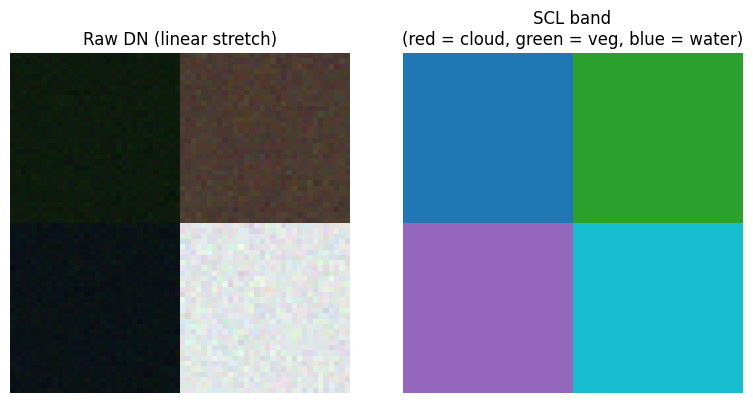

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))
rgb_dn = np.stack([dn_stack[2], dn_stack[1], dn_stack[0]], axis=-1)  # R, G, B
ax[0].imshow(rgb_dn / rgb_dn.max())
ax[0].set_title("Raw DN (linear stretch)")
ax[0].axis("off")
ax[1].imshow(scl, cmap="tab10")
ax[1].set_title("SCL band\n(red = cloud, green = veg, blue = water)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 2. Radiometry — DN → reflectance + display stretch

`gz.radiometry.DNToReflectance(scale=1e-4)` is the Sentinel-2 L1C
shortcut: it absorbs solar geometry into a single per-scene scale
factor. Apply it to recover physical reflectance in `[0, 1]`.
`gz.radiometry.PercentileClip` + `Gamma` then prepare the result for
display.

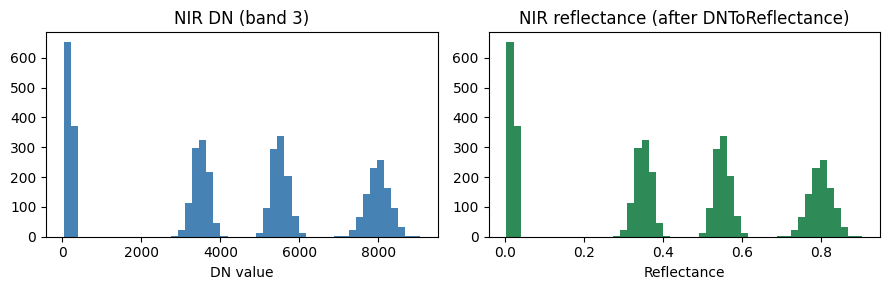

In [4]:
to_reflectance = gz.radiometry.DNToReflectance(scale=1e-4)
reflectance = to_reflectance(gt)

# Histogram of one band, before and after.
fig, ax = plt.subplots(1, 2, figsize=(9, 3))
ax[0].hist(np.asarray(gt)[3].ravel(), bins=50, color="steelblue")
ax[0].set_title("NIR DN (band 3)")
ax[0].set_xlabel("DN value")
ax[1].hist(np.asarray(reflectance)[3].ravel(), bins=50, color="seagreen")
ax[1].set_title("NIR reflectance (after DNToReflectance)")
ax[1].set_xlabel("Reflectance")
plt.tight_layout()
plt.show()

Build a small display pipeline. `ToFloat32` is the first stop (DN are
`uint16`); `PercentileClip` does a robust per-band 2-98 % stretch;
`Gamma(1.2)` brightens midtones.

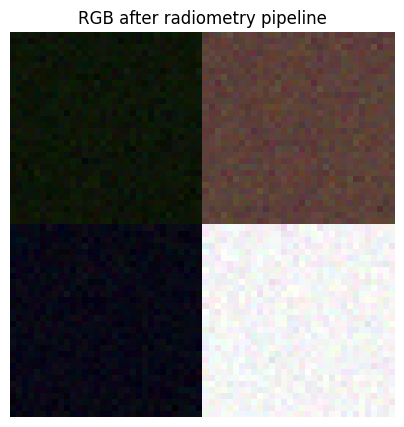

In [5]:
display_pipe = (
    gz.radiometry.ToFloat32()
    | gz.radiometry.DNToReflectance(scale=1e-4)
    | gz.radiometry.PercentileClip(p_min=2.0, p_max=98.0)
    | gz.radiometry.Gamma(g=1.2)
)

# Drop the SCL band before display (otherwise we'd stretch it too).
spectral_gt = GeoTensor(
    np.asarray(gt)[:4],
    transform=gt.transform,
    crs=gt.crs,
    fill_value_default=gt.fill_value_default,
)
display = display_pipe(spectral_gt)
rgb_display = np.stack(
    [np.asarray(display)[2], np.asarray(display)[1], np.asarray(display)[0]],
    axis=-1,
)

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(rgb_display)
ax.set_title("RGB after radiometry pipeline")
ax.axis("off")
plt.show()

## 3. Cloud masking — SCL → boolean mask

`gz.cloud.MaskFromSCL` pulls the SCL band and returns True where the
class is in the supplied set. `gz.cloud.SCL_CLOUDS` is the canonical
"everything cloudy" bundle (`{CLOUD_MEDIUM, CLOUD_HIGH, THIN_CIRRUS}`).

cloud_mask shape: (64, 64)
cloud-covered fraction: 25.0%


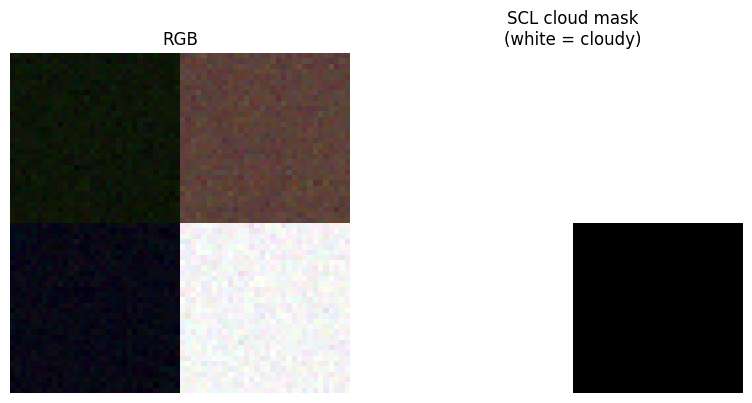

In [6]:
cloud_mask_op = gz.cloud.MaskFromSCL(band_idx=-1, classes=gz.cloud.SCL_CLOUDS)
cloud_mask = cloud_mask_op(gt)

print(f"cloud_mask shape: {cloud_mask.shape}")
print(f"cloud-covered fraction: {np.mean(np.asarray(cloud_mask)):.1%}")

fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(rgb_display)
ax[0].set_title("RGB")
ax[0].axis("off")
ax[1].imshow(np.asarray(cloud_mask), cmap="gray_r")
ax[1].set_title("SCL cloud mask\n(white = cloudy)")
ax[1].axis("off")
plt.tight_layout()
plt.show()

## 4. Apply the mask + compute NDVI

`gz.cloud.ApplyMask` fills masked-out pixels with `np.nan` (the right
choice for float reflectance — propagates through downstream arithmetic
instead of biasing it). Pass `mask=<Operator>` to have it run the
mask-extraction step on the same input first.

In [7]:
# Step-by-step: reflectance → mask → NDVI
step1 = gz.radiometry.DNToReflectance(scale=1e-4)(gt)
step2 = gz.cloud.ApplyMask(mask=cloud_mask_op, fill_value=np.nan)(step1)
step3 = gz.indices.NDVI(nir_idx=3, red_idx=2)(step2)

# All in one Sequential:
ndvi_pipeline = (
    gz.radiometry.DNToReflectance(scale=1e-4)
    | gz.cloud.ApplyMask(
        mask=gz.cloud.MaskFromSCL(band_idx=-1, classes=gz.cloud.SCL_CLOUDS),
        fill_value=np.nan,
    )
    | gz.indices.NDVI(nir_idx=3, red_idx=2)
)
ndvi_pipe_result = ndvi_pipeline(gt)

# The two paths should produce identical output (modulo NaN equality).
manual = np.asarray(step3)
piped = np.asarray(ndvi_pipe_result)
np.testing.assert_array_equal(np.isnan(manual), np.isnan(piped))
np.testing.assert_allclose(
    manual[~np.isnan(manual)], piped[~np.isnan(piped)], rtol=1e-6
)
print("manual and Sequential paths agree.")

manual and Sequential paths agree.


Visualise. The cloudy quadrant is NaN (matplotlib renders it white by
default with a masked colormap); the vegetation quadrant has high
NDVI; soil sits near zero; water is negative.

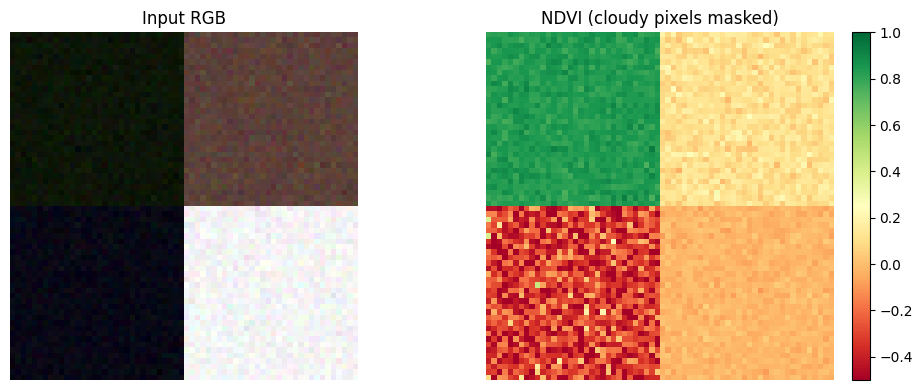

In [8]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].imshow(rgb_display)
ax[0].set_title("Input RGB")
ax[0].axis("off")
im = ax[1].imshow(piped, cmap="RdYlGn", vmin=-0.5, vmax=1.0)
ax[1].set_title("NDVI (cloudy pixels masked)")
ax[1].axis("off")
plt.colorbar(im, ax=ax[1], fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

## 5. Summary

The three operator modules compose cleanly:

- **`gz.radiometry`** handles the DN → reflectance → display chain.
  Six generic operators; sensor presets land in v0.4.
- **`gz.cloud`** turns categorical / bitmask QA bands into boolean
  masks and applies them to the carrier.
  `gz.cloud.SCL_CLOUDS` and friends are the convenient class bundles
  for Sentinel-2 L2A workflows.
- **`gz.indices`** wraps the spectral-index math (NDVI, NDWI, NDBI,
  NBR, SAVI, EVI) plus a generic `NormalizedDifference` and an
  `AppendIndex` composition helper.

Every Operator carries a `get_config()` that round-trips through
`hydra_zen.builds()`, so an entire RS pipeline can be declared in YAML
and instantiated at runtime.

## Watermark

In [9]:
try:
    import watermark.watermark as watermark

    print(
        watermark(
            packages="numpy,rasterio,georeader_spaceml,geotoolz,matplotlib",
        )
    )
except ImportError:
    pass

numpy            : 2.4.4
rasterio         : 1.5.0
georeader_spaceml: 2.1.0
geotoolz         : 0.0.4
matplotlib       : 3.10.8

